In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [31]:
RUNS_DIR = Path.cwd().parent / "runs"

sweep-64x64:    80
sweep-128x128:  144
sweep-256x256:  256
sweep-mixed:    240


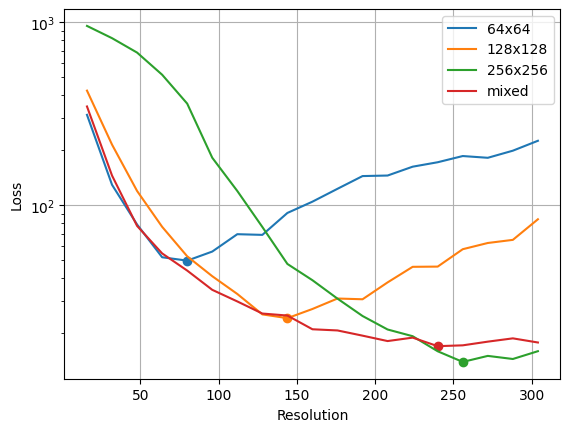

In [ ]:
for run_name in ["sweep-64x64", "sweep-128x128", "sweep-256x256", "sweep-mixed"]:
    data = pd.read_csv(RUNS_DIR / run_name / "test-results.csv")
    sizes = [int(x.split("x")[0]) for x in data["dataset"].tolist() if x != "all-avg"]
    losses = data.loc[data["dataset"] != "all-avg"][" value"].tolist()
    plt.plot(sizes, losses, label=run_name.split("-")[1])
    best_i = np.argmin(losses)
    plt.scatter(sizes[best_i], losses[best_i])
    print(f"{run_name+':':15} {sizes[best_i]}")
plt.xlabel("Resolution")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.grid()

#Show/Subtract baseline